<div style="font-family: Calibri; background-color: #ccd5ae; padding: 10px 10px;">
    <h1>Ensemble - BalancedRandomForest</h1>
</div>

In [1]:
import pandas as pd
import numpy as np
import warnings
from sklearn import set_config
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from scripts.plot_tetha import plot_model
import seaborn as sns
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, make_scorer, confusion_matrix, fbeta_score

In [2]:
%load_ext autoreload
%autoreload 2
from scripts.scores import calc_predict_proba, calc_scores, confusion_matrix_display, print_evaluation
from scripts.decision_tree import determine_parameter

In [3]:
warnings.filterwarnings("ignore") 
set_config(display='diagram')
pd.options.display.precision=3
pd.set_option('display.float_format', lambda x: '%.3f' % x)

<div style="font-family: Calibri; background-color: #faedcd; padding: 5px;">
    <h2>1. Loading Train and Test dataset</h2>
</div>

In [4]:
df = pd.read_csv("data/train.csv" )
df.shape

(255347, 18)

In [5]:
X = df.drop(columns=['Default', 'LoanID', 'DTIRatio', 'CreditScore'])
y = df['Default']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print(X_train.shape, X_test.shape,  y_train.shape, y_test.shape)

(204277, 14) (51070, 14) (204277,) (51070,)


<hr>
<div style="font-family: Calibri; background-color: #faedcd; padding: 5px 5px 5px 5px;">
    <h2>2. Column Transformation</h2>
</div>

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler

<div style="font-family: Calibri; font-size: 18px; background-color: #fefae0; padding: 3px 3px 3px 10px;">
    <h3>Univariate Analysis - Conclusion (Recap)</h3>    
    <ul>
            <li>HasCoSigner, HasDependents, HasMortgage are binary fields</li>
            <li>Education, EmploymentType, LoanPurpose, MaritalStatus are categorical data</li>
    </ul>        
    <h4>Transformation is done external to pipeline to avoid the redundent step In GridSearchCV
    </h4>
</div>

In [8]:
transformer = ColumnTransformer(
    [
        ('Binary', OneHotEncoder(drop='if_binary'), ['HasCoSigner', 'HasDependents', 'HasMortgage']),
        ('multi_category', OneHotEncoder(),  ['Education', 'EmploymentType', 'MaritalStatus']),
        ('Loan_category', OneHotEncoder(categories = [['Business', 'Home']], handle_unknown='ignore'), ['LoanPurpose']),    
    ], remainder='passthrough'
)

In [9]:
X_train = transformer.fit_transform(X_train)

In [10]:
X_test = transformer.transform(X_test)

<div style="font-family: Calibri; background-color: #faedcd; padding: 5px;">
    <h2>3. Determine The Decision Tree Parameters</h2>
</div>

In [11]:
from imblearn.ensemble import BalancedRandomForestClassifier

<div style="font-family: Calibri; background-color: #fefae0; padding: 3px 3px 3px 10px;">
    <h4>1. max_depth</h4>    
    <ul>
            <li>Purpose: Limits the depth (number of levels) of the tree.</li>
            <li>Tip: A very deep tree can overfit; setting a maximum depth helps control model complexity.</li>
    </ul>        
</div>

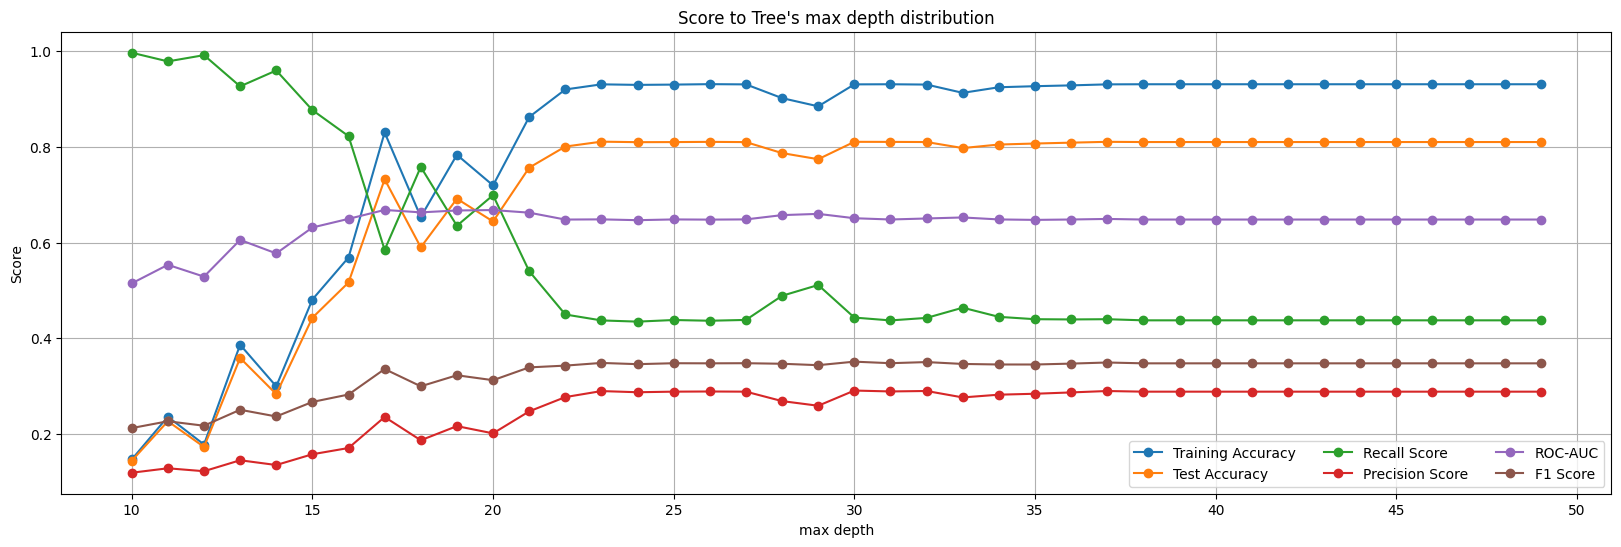

In [12]:
determine_parameter(X_train, y_train, X_test, y_test, BalancedRandomForestClassifier, "max_depth", range(10,50))

<div style="font-family: Calibri; background-color: #fefae0; padding: 3px 3px 3px 10px;">
    <h4>2. min_samples_split</h4>    
    <ul>
        <li>Purpose: The minimum number of samples required to split an internal node.</li>
        <li>Tip: Increasing this value can make the tree more general and reduce overfitting.</li>
    </ul>        
</div>

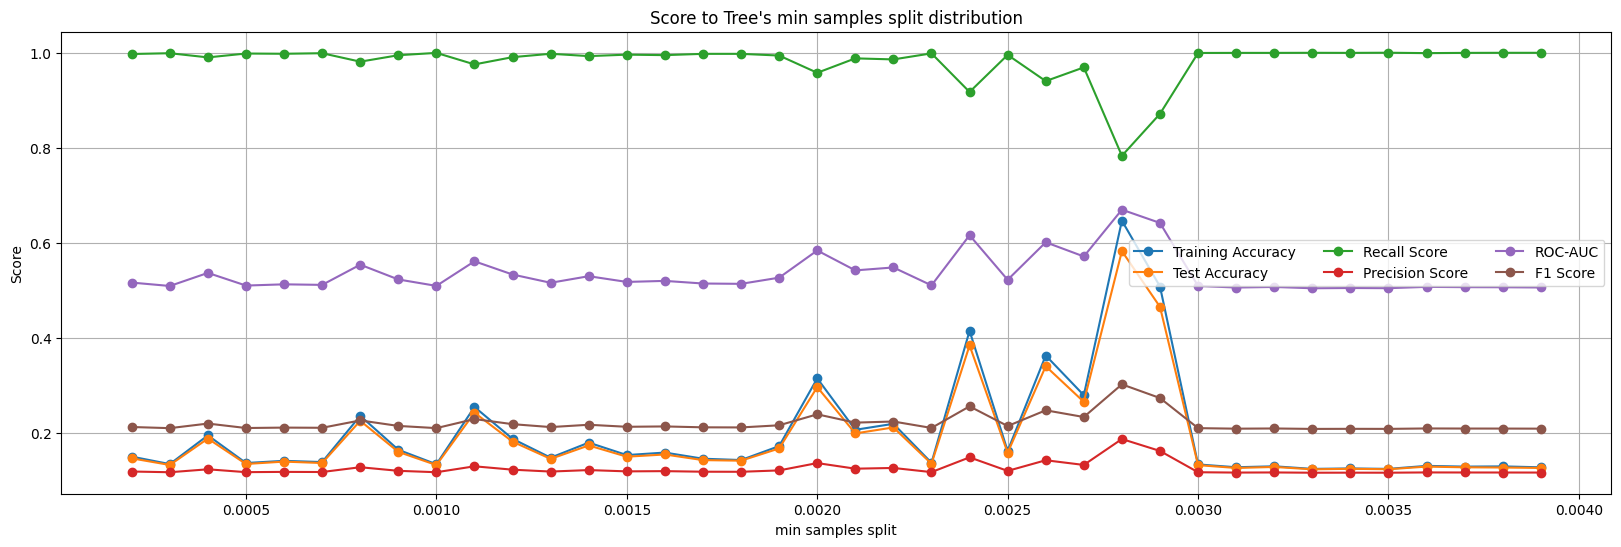

In [13]:
determine_parameter(X_train, y_train, X_test, y_test, BalancedRandomForestClassifier,"min_samples_split", np.arange(0.0002,0.004,0.0001))

<div style="font-family: Calibri; background-color: #fefae0; padding: 3px 3px 3px 10px;">
    <h4>3. min_samples_leaf</h4>    
    <ul>
        <li>Purpose: The minimum number of samples required to be at a leaf node.</li>
        <li>Tip: Larger values can reduce variance (smoothing the model), which might help avoid overfitting.</li>
    </ul>        
</div>

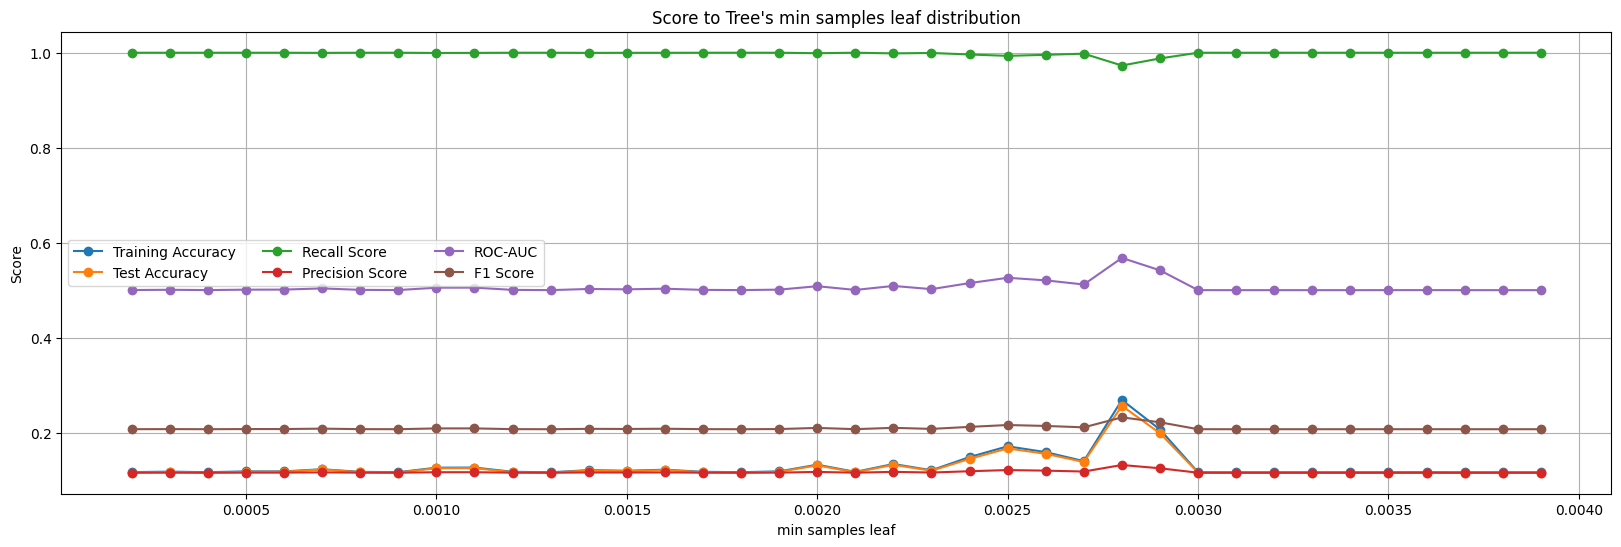

In [14]:
determine_parameter(X_train, y_train, X_test, y_test, BalancedRandomForestClassifier,"min_samples_leaf", np.arange(0.0002,0.004,0.0001))

<div style="font-family: Calibri; background-color: #fefae0; padding: 3px 3px 3px 10px;">
    <h4>4. max_features</h4>    
    <ul>
        <li>Purpose: The number of features to consider when looking for the best split.</li>
    </ul>        
</div>

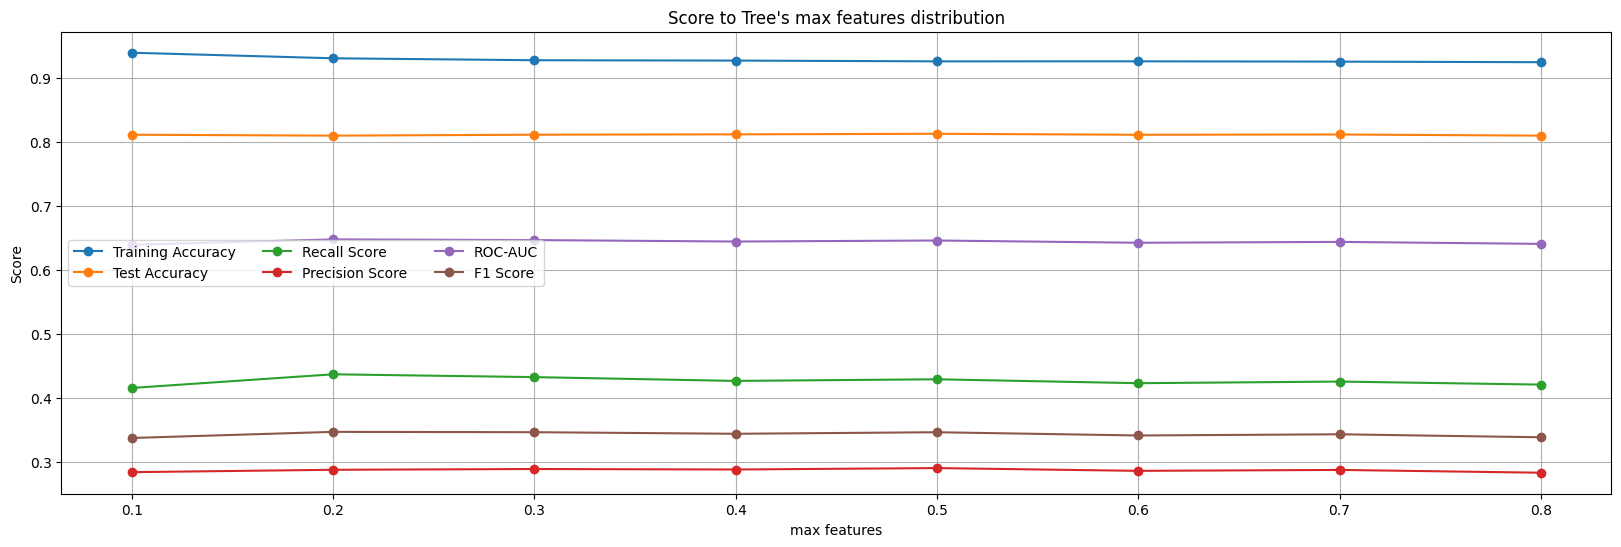

In [15]:
determine_parameter(X_train, y_train, X_test, y_test, BalancedRandomForestClassifier,"max_features", np.arange(0.1,0.9,0.1))

<div style="font-family: Calibri; background-color: #fefae0; padding: 3px 3px 3px 10px;">
    <h4>5. min_impurity_decrease</h4>    
    <ul>
        <li>A node will be split if this split induces a decrease of the impurity greater than or equal to this value.</li>
    </ul>        
</div>

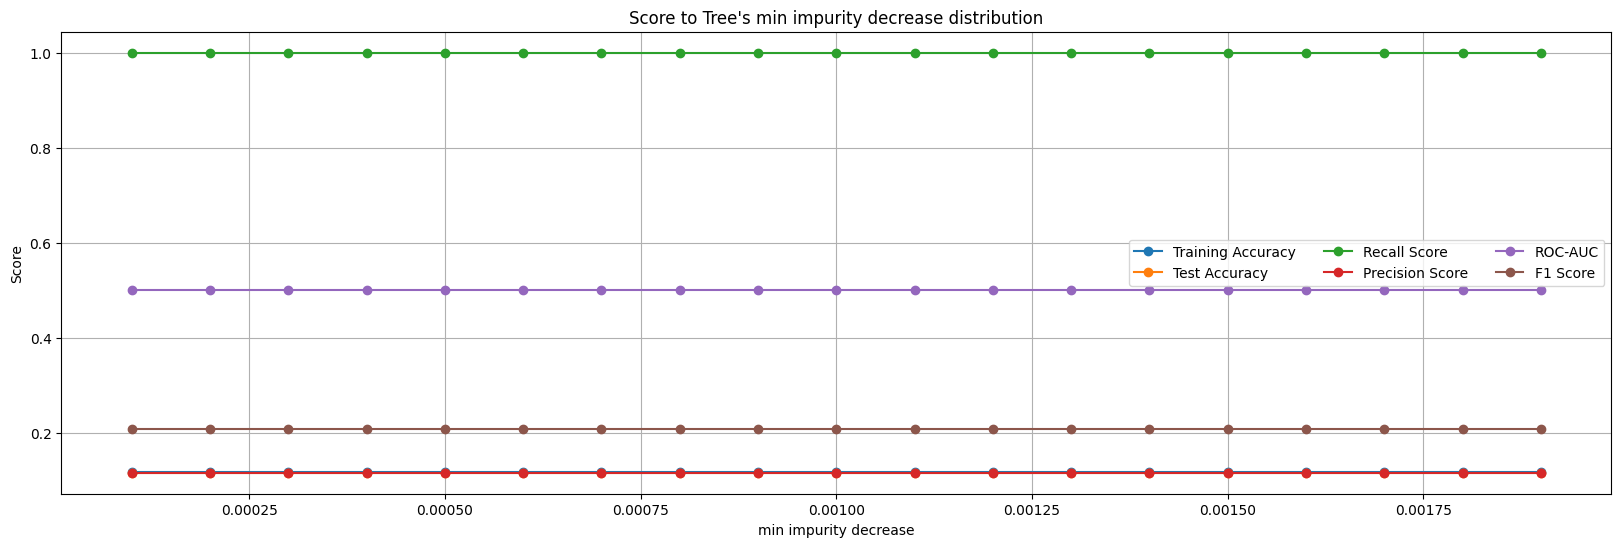

In [16]:
determine_parameter(X_train, y_train, X_test, y_test, BalancedRandomForestClassifier,"min_impurity_decrease", np.arange(0.0001,0.002,0.0001))

<div style="font-family: Calibri; font-size: 18px; background-color: #fefae0; padding: 3px 3px 3px 10px;">
    <h3>Decision Tree's Parameter Analysis Conclusion</h3>  
    <ul>
        <li>min_samples_split &#x2705;</li>        
        <ul>
            <li>Recall score best range static is between 0.10 to 0.20</li>            
        </ul>
    </ul>        
    <ul>
        <li>min_samples_leaf &#x274C;</li>        
        <ul>
            <li>Recall score best range is stabilized at 0.15. Score went above 60%</li>            
        </ul>
    </ul>            
    <ul>
        <li>min_impurity_decrease &#x274C;</li>  
        <li>max_features &#x274C;</li>
        <ul><li>The graph for these 3 features pretty much is flat line, indicating this parementer does not contribute enough to improve prediction</li></ul>
    </ul>        
    <ul>
        <li>max_depth  &#x2705;</li>        
        <ul>
            <li>The recall score is readually decreasing as depth increases</li>
            <li>Training and Test score were in upword trend, indicating accuracy getting better. But simultanelously Recall, and precision score are decreasing</li>
            </li>Peak is at aroung 11</li>
        </ul>
    </ul>        
</div>

<div style="font-family: Calibri; font-size: 16px; background-color: #faedcd; padding: 5px;">
    <h2>4. DecisionTree</h2>
    <font size=4>        
    <ul>
        <li>GridSearchCV</li>
        <li>Decision Tree using class weight</li>
    </ul>
    </font>
</div>

In [17]:
classifier = BalancedRandomForestClassifier(
     n_estimators= 15,
     class_weight='balanced',
     random_state=42,
     sampling_strategy='auto',
     replacement=True,
     n_jobs=-1
)

In [18]:
param_grid = [
    {
        "min_samples_split": np.arange(0.0002,0.003,0.0001),
        'max_depth': range(17,20,1)
    },
    {    
        'max_depth': range(17,20,1)
    },
    {
        "min_samples_split": np.arange(0.0002,0.003,0.0001)
    }
]

In [19]:
#scoring = {'accuracy': make_scorer(fbeta_score, beta=2, pos_label=1), 'prec': 'precision'} 'balanced_accuracy'
cv = GridSearchCV(classifier, param_grid, cv=5, n_jobs=-1, verbose=True, scoring=make_scorer(fbeta_score, beta=2, pos_label=1));

In [20]:
cv.fit(X_train, y_train)

Fitting 5 folds for each of 115 candidates, totalling 575 fits


GridSearchCV(cv=5,
             estimator=BalancedRandomForestClassifier(class_weight='balanced',
                                                      n_estimators=15,
                                                      n_jobs=-1,
                                                      random_state=42,
                                                      sampling_strategy='auto'),
             n_jobs=-1,
             param_grid=[{'max_depth': range(17, 20),
                          'min_samples_split': array([0.0002, 0.0003, 0.0004, 0.0005, 0.0006, 0.0007, 0.0008, 0.0009,
       0.001 , 0.0011, 0.0012, 0.0013, 0.0014, 0.0015, 0.0016, 0.0017,
       0.0018, 0.0019...
       0.0026, 0.0027, 0.0028, 0.0029])},
                         {'max_depth': range(17, 20)},
                         {'min_samples_split': array([0.0002, 0.0003, 0.0004, 0.0005, 0.0006, 0.0007, 0.0008, 0.0009,
       0.001 , 0.0011, 0.0012, 0.0013, 0.0014, 0.0015, 0.0016, 0.0017,
       0.0018, 0.0019, 0.002 , 0.0021, 0.0022, 0.0023, 0.0024, 0.0025,
       0.0026, 0.0027, 0.0028, 0.0029])}],
             scoring=make_scorer(fbeta_score, response_method='predict', beta=2, pos_label=1),
             verbose=True)

In [21]:
print("Best Parameters:", cv.best_params_)
print("Best CV Score:", cv.best_score_)

Best Parameters: {'max_depth': 19}
Best CV Score: 0.4559537919687095


In [22]:
model = cv.best_estimator_
model

BalancedRandomForestClassifier(class_weight='balanced', max_depth=19,
                               n_estimators=15, n_jobs=-1, random_state=42,
                               sampling_strategy='auto')

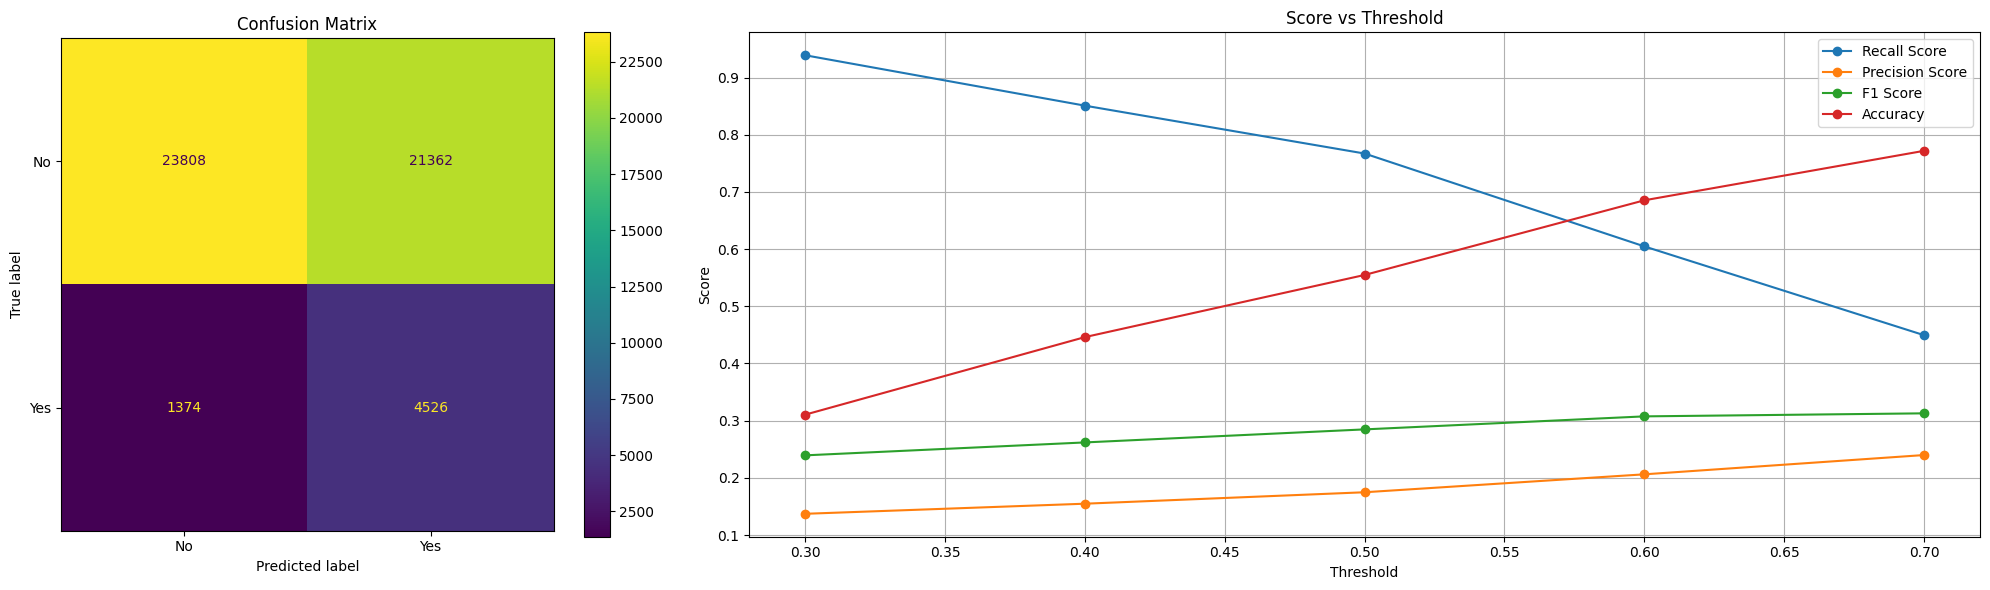

,Score,Percentage
0,Training Accuracy,64.17%
1,Test Accuracy,55.48%
2,Recall Score,44.95%
3,Precision Score,23.99%
4,Accuracy Score,77.19%
5,F1 Score,31.28%
6,ROC AUC Score,64.71%


In [23]:
scores_df, threshold_df = print_evaluation(model, X_train, y_train, X_test, y_test)
scores_df

In [24]:
threshold_df

,recall,precision,f1-score,accuracy
0.300,0.939,0.137,0.239,0.311
0.400,0.851,0.155,0.262,0.446
0.500,0.767,0.175,0.285,0.555
0.600,0.605,0.206,0.308,0.685
0.700,0.449,0.240,0.313,0.772
